In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df= pd.read_csv("house_price_prediction_dataset.csv")


In [3]:

print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")


rows: 125, columns: 9


In [4]:
#summmary statistics
print(df.describe())

          House_ID      Area_m2    Bedrooms   Bathrooms  House_Age_Years  \
count   125.000000   123.000000  124.000000  124.000000       124.000000   
mean   1059.000000   134.808943    3.298387    3.016129         9.773387   
std      34.938887   133.300251    1.216284    1.202868        10.435564   
min    1001.000000    26.000000    1.000000    1.000000         0.400000   
25%    1028.000000    82.450000    2.000000    2.000000         3.175000   
50%    1058.000000   107.900000    3.000000    3.000000         6.650000   
75%    1089.000000   141.000000    4.000000    4.000000        12.125000   
max    1120.000000  1200.000000    6.000000    5.000000        75.000000   

       Distance_to_City_km  Parking_Spaces  House_Price_Million_RWF  
count           124.000000      124.000000               124.000000  
mean              5.652419        1.185484               173.254032  
std               8.701097        0.849361               127.372543  
min               0.070000        0

In [5]:
#print datatype of each column
print(df.dtypes)

House_ID                     int64
Area_m2                    float64
Bedrooms                   float64
Bathrooms                  float64
House_Age_Years            float64
Distance_to_City_km        float64
Parking_Spaces             float64
Neighborhood                   str
House_Price_Million_RWF    float64
dtype: object


In [6]:
#display first rows
df.head()

,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
0,1001,144.6,2.0,2.0,15.0,27.40,0.0,Kigali City,104.8
1,1002,101.9,4.0,4.0,15.5,5.97,1.0,Huye,137.0
2,1003,157.1,3.0,2.0,8.9,2.42,1.0,Nyarugenge,171.6
3,1004,254.2,3.0,2.0,15.5,6.68,1.0,Musanze,197.2
4,1005,96.7,3.0,2.0,9.5,12.34,2.0,Gasabo,121.8


In [7]:
#summary statistics
df.describe(include="all")

,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
count,125.000000,123.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124,124.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Huye,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN
mean,1059.000000,134.808943,3.298387,3.016129,9.773387,5.652419,1.185484,NaN,173.254032
std,34.938887,133.300251,1.216284,1.202868,10.435564,8.701097,0.849361,NaN,127.372543
min,1001.000000,26.000000,1.000000,1.000000,0.400000,0.070000,0.000000,NaN,77.700000
25%,1028.000000,82.450000,2.000000,2.000000,3.175000,1.557500,1.000000,NaN,118.525000
50%,1058.000000,107.900000,3.000000,3.000000,6.650000,3.535000,1.000000,NaN,150.650000
75%,1089.000000,141.000000,4.000000,4.000000,12.125000,7.072500,2.000000,NaN,186.675000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   House_ID                 125 non-null    int64  
 1   Area_m2                  123 non-null    float64
 2   Bedrooms                 124 non-null    float64
 3   Bathrooms                124 non-null    float64
 4   House_Age_Years          124 non-null    float64
 5   Distance_to_City_km      124 non-null    float64
 6   Parking_Spaces           124 non-null    float64
 7   Neighborhood             124 non-null    str    
 8   House_Price_Million_RWF  124 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 9.8 KB


In [9]:
# 1. Count missing values per column
print("--- Missing Values Count ---")
print(df.isnull().sum())
print("\n")

--- Missing Values Count ---
House_ID                   0
Area_m2                    2
Bedrooms                   1
Bathrooms                  1
House_Age_Years            1
Distance_to_City_km        1
Parking_Spaces             1
Neighborhood               1
House_Price_Million_RWF    1
dtype: int64




In [10]:
# Drop the row where the target (house price) is missing
df = df.dropna(subset=['House_Price_Million_RWF'])

# Impute numerical columns with their median
numeric_cols = [
    'Area_m2',
    'Bedrooms',
    'Bathrooms',
    'House_Age_Years',
    'Distance_to_City_km',
    'Parking_Spaces'
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Impute categorical column with its mode
df['Neighborhood'] = df['Neighborhood'].fillna(df['Neighborhood'].mode()[0])


print(df.isnull().sum())


House_ID                   0
Area_m2                    0
Bedrooms                   0
Bathrooms                  0
House_Age_Years            0
Distance_to_City_km        0
Parking_Spaces             0
Neighborhood               0
House_Price_Million_RWF    0
dtype: int64


In [11]:
# Count duplicate rows
df.duplicated().sum()



np.int64(5)

In [12]:
#duplicated rows
df[df.duplicated()]


,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
120,1011,85.3,1.0,1.0,8.7,0.93,2.0,Gasabo,99.8
121,1026,116.9,5.0,4.0,5.0,14.11,0.0,Huye,140.4
122,1041,165.1,5.0,5.0,6.2,8.84,0.0,Huye,236.2
123,1011,85.3,1.0,1.0,8.7,0.93,2.0,Gasabo,99.8
124,1026,116.9,5.0,4.0,5.0,14.11,0.0,Huye,140.4


In [13]:
#removing duplicates
df = df.drop_duplicates()
print("Number of rows after removing duplicates:", len(df))
print("Number of duplicate rows:", df.duplicated().sum())


Number of rows after removing duplicates: 119
Number of duplicate rows: 0


In [14]:
# ==========================================
# OUTLIER DETECTION USING THE IQR METHOD
# ==========================================

numeric_cols = [
    'Area_m2',
    'Bedrooms',
    'Bathrooms',
    'House_Age_Years',
    'Distance_to_City_km',
    'Parking_Spaces',
    'House_Price_Million_RWF'
]

print("\n--- Outlier Detection using IQR ---")

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Number_of_Outliers': len(outliers)
    })

    print(f"\n{col}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")

outlier_summary = pd.DataFrame(outlier_summary)

print("--- Outlier Summary ---")
print(outlier_summary)



--- Outlier Detection using IQR ---

Area_m2
Q1: 82.45
Q3: 141.00
IQR: 58.55
Lower bound: -5.37
Upper bound: 228.82
Number of outliers: 12

Bedrooms
Q1: 2.00
Q3: 4.00
IQR: 2.00
Lower bound: -1.00
Upper bound: 7.00
Number of outliers: 0

Bathrooms
Q1: 2.00
Q3: 4.00
IQR: 2.00
Lower bound: -1.00
Upper bound: 7.00
Number of outliers: 0

House_Age_Years
Q1: 3.00
Q3: 12.25
IQR: 9.25
Lower bound: -10.88
Upper bound: 26.12
Number of outliers: 9

Distance_to_City_km
Q1: 1.57
Q3: 6.80
IQR: 5.23
Lower bound: -6.27
Upper bound: 14.64
Number of outliers: 7

Parking_Spaces
Q1: 1.00
Q3: 2.00
IQR: 1.00
Lower bound: -0.50
Upper bound: 3.50
Number of outliers: 0

House_Price_Million_RWF
Q1: 120.15
Q3: 186.95
IQR: 66.80
Lower bound: 19.95
Upper bound: 287.15
Number of outliers: 4
--- Outlier Summary ---
                    Column      Q1      Q3    IQR  Lower_Bound  Upper_Bound  \
0                  Area_m2   82.45  141.00  58.55       -5.375      228.825   
1                 Bedrooms    2.00    4.00   

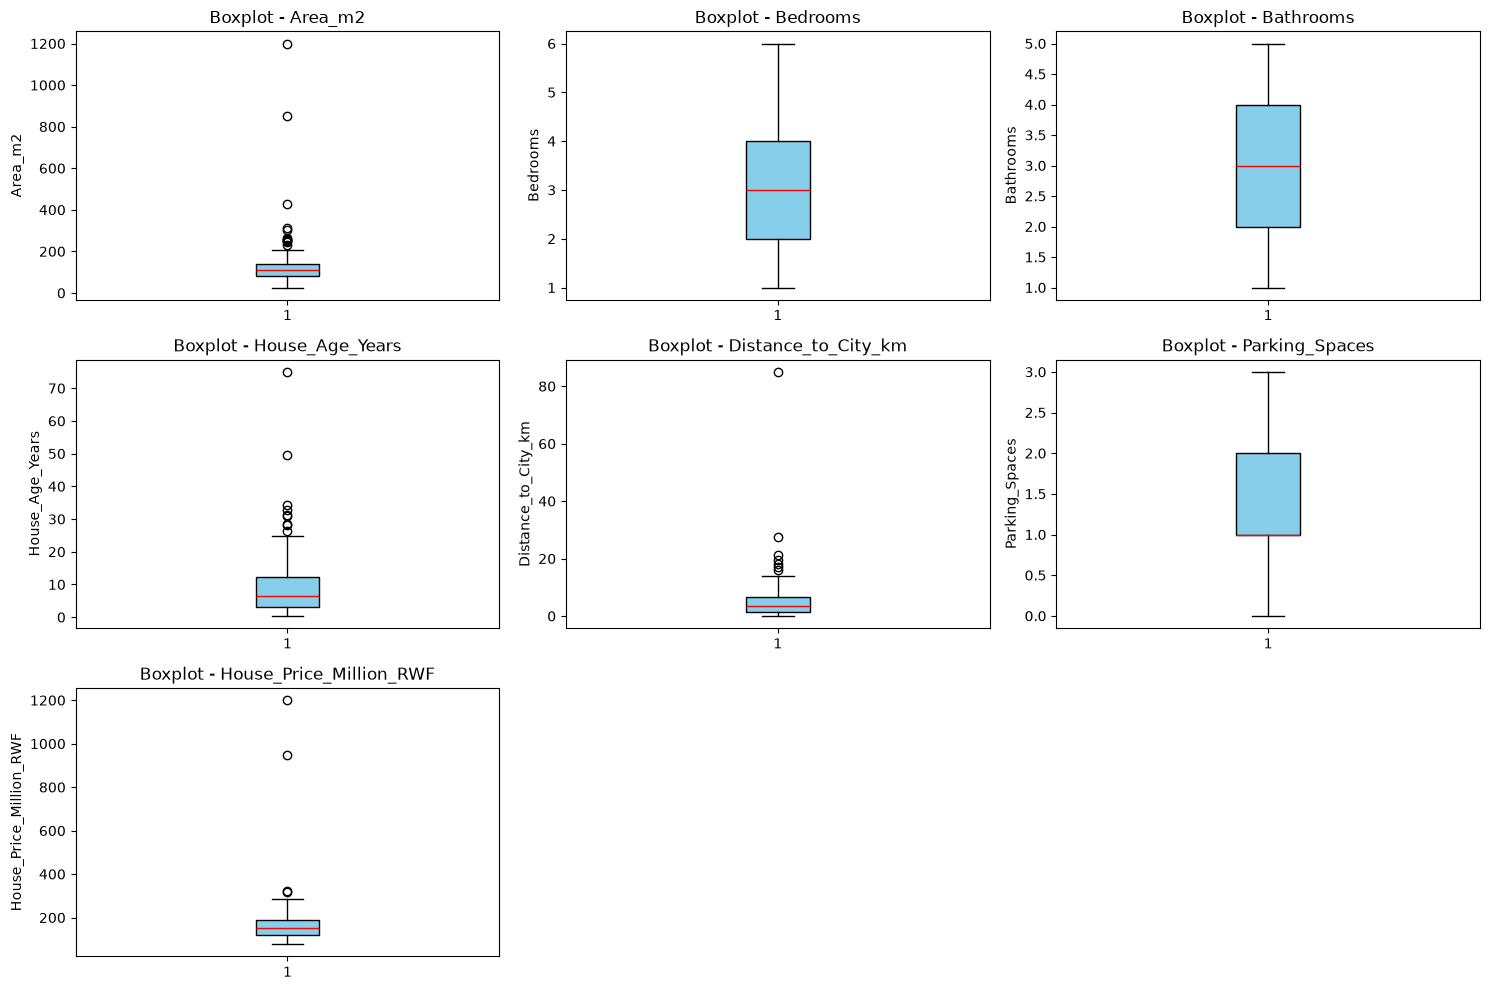

In [15]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)

    plt.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='skyblue'),
        medianprops=dict(color='red')
    )

    plt.title(f'Boxplot - {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


In [16]:
# Remove observations with impossible values

df = df[
    (df['Area_m2'] > 0) &
    (df['Bedrooms'] >= 0) &
    (df['Bathrooms'] >= 0) &
    (df['House_Age_Years'] >= 0) &
    (df['Distance_to_City_km'] >= 0) &
    (df['Parking_Spaces'] >= 0) &
    (df['House_Price_Million_RWF'] > 0)
]

print("Rows after removing impossible values:", len(df))


Rows after removing impossible values: 119


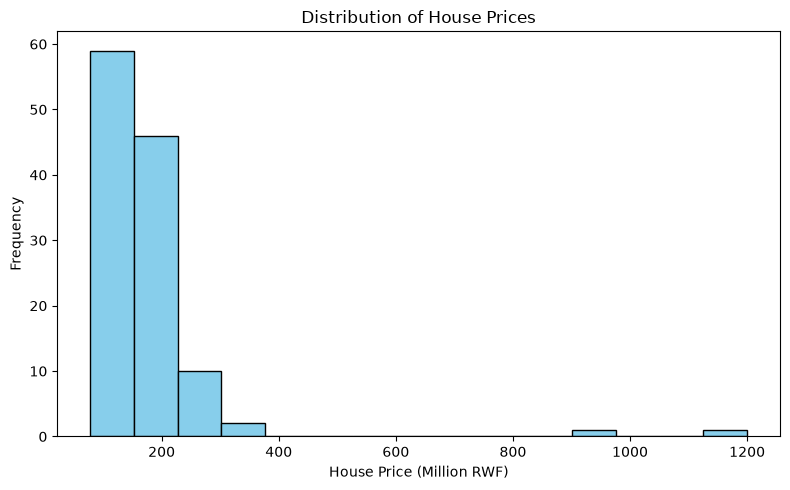

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['House_Price_Million_RWF'].dropna(),
    bins=15,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of House Prices')
plt.xlabel('House Price (Million RWF)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


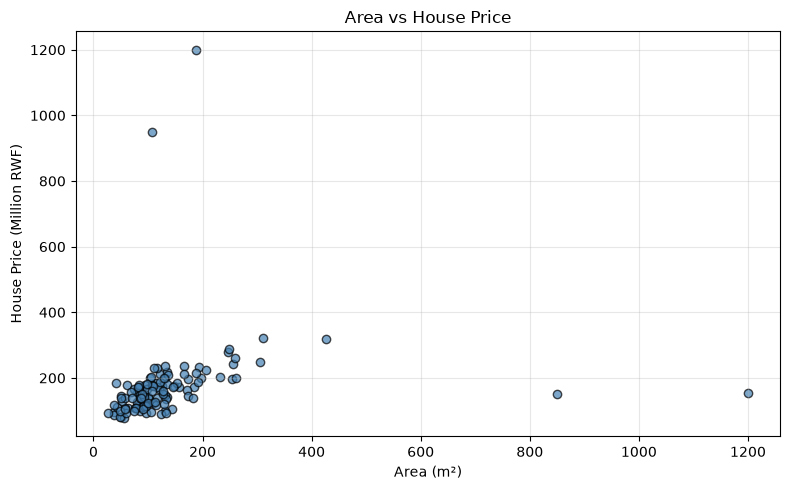

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Area_m2'],
    df['House_Price_Million_RWF'],
    color='steelblue',
    alpha=0.7,
    edgecolors='black'
)

plt.title('Area vs House Price')
plt.xlabel('Area (m²)')
plt.ylabel('House Price (Million RWF)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


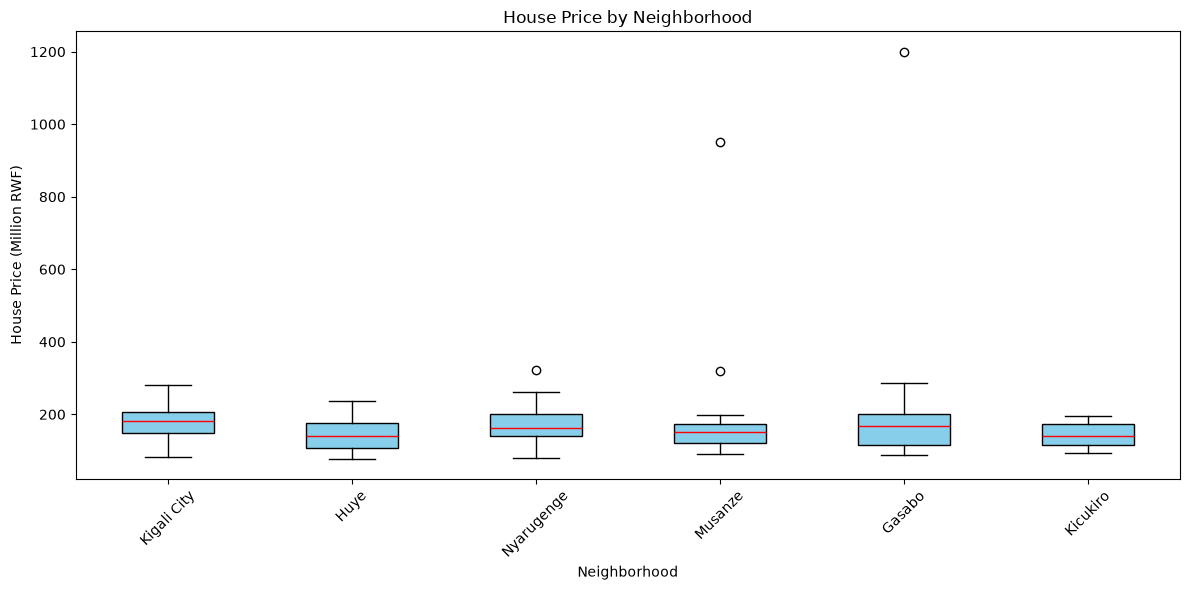

In [19]:
plt.figure(figsize=(12, 6))

neighborhoods = df['Neighborhood'].dropna().unique()

price_data = [
    df.loc[
        df['Neighborhood'] == neighborhood,
        'House_Price_Million_RWF'
    ].dropna()
    for neighborhood in neighborhoods
]

plt.boxplot(
    price_data,
    tick_labels=neighborhoods,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue'),
    medianprops=dict(color='red')
)

plt.title('House Price by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('House Price (Million RWF)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
